# Nightlights in Syria after Regime Change

This notebook looks into the change in nightlights after regime change in Syria. Specifically, it focusses on gas flaring locations to estimate if more oil production is ahppening after the regime change. 

In [49]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

syria_adm0 = gpd.read_file('../../data/boundaries/syr_admin0.shp')

In [50]:
from pathlib import Path
# Set DATA_DIR to the root data directory for this project
DATA_DIR = Path('../../data')


In [51]:
import os

if "BLACKMARBLE_TOKEN" in os.environ:
    blackmarble_token = os.environ["BLACKMARBLE_TOKEN"]
else:
    import getpass
    blackmarble_token = getpass.getpass("Enter your Blackmarble token: ")

In [63]:
# from blackmarble import bm_raster, bm_extract


# rasters = bm_raster(
#     gdf = syria_adm0,
#     product_id='VNP46A4',
#     date_range=pd.date_range('2023-01-01', '2025-01-01', freq='YS'),
#     token = blackmarble_token,
#     output_directory=str(DATA_DIR / f'ntl/raw/'),
#     output_skip_if_exists=True    
# )

In [64]:
# # Save each time slice as a separate file in the format monthly-raster_YYYY-MM.tif
# for t in rasters.time.values:
#     date_str = pd.to_datetime(t).strftime("%Y")
#     out_path = DATA_DIR / f"ntl/raw/annual-raster_{date_str}.tif"
#     rasters.sel(time=t).rio.to_raster(out_path)
#     print(f"Saved: {out_path}")

In [ ]:
syria_adm1 = gpd.read_file('../../data/boundaries/syr_admin1.shp')

## Annual Change in Nightlights 

2023 and 2025 are compared with 2024 to look at how lights changed before and after regime change. The annual nightlight product is more stable than using monthly product and thus, may be more useful in identifying actual change in lights. 

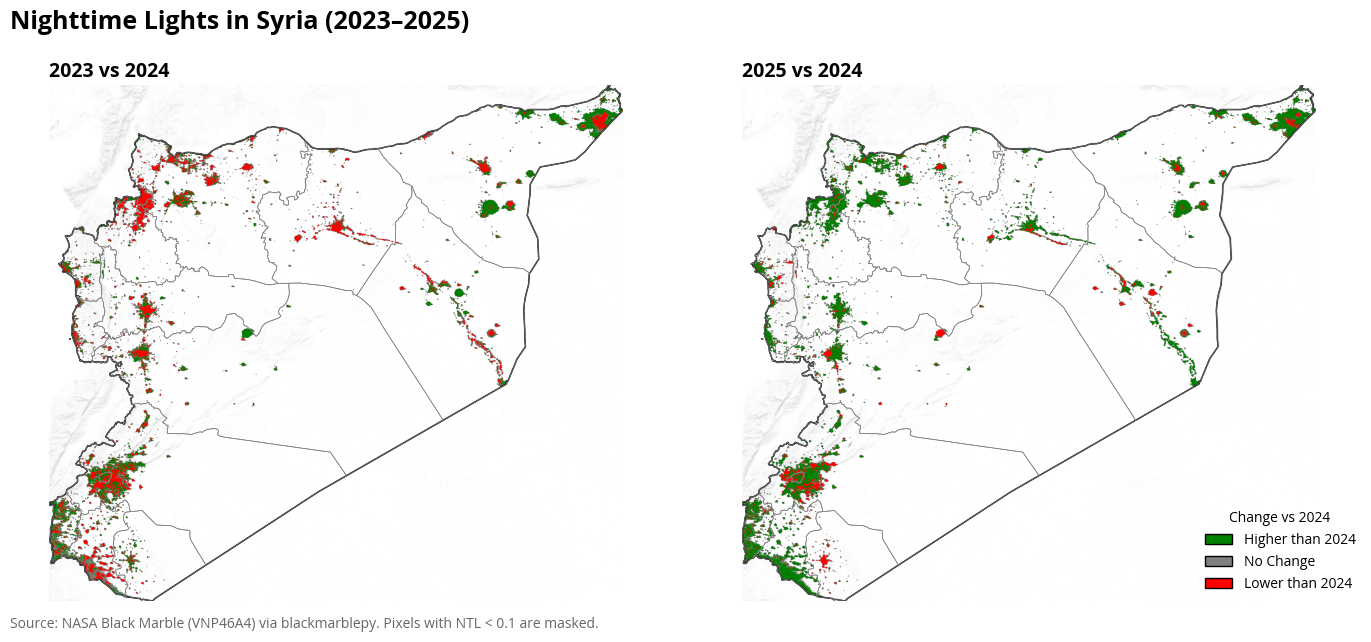

In [ ]:
import os
import rasterio
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
import contextily as ctx
from dotenv import load_dotenv
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

load_dotenv()
MAPBOX_BASEMAP_URL = os.getenv('MAPBOX_BASEMAP_URL', '')
plt.rcParams['font.family'] = 'Open Sans'

# Load admin boundaries
syria_adm0 = gpd.read_file('../../data/boundaries/syr_admin0.shp')
syria_adm1 = gpd.read_file('../../data/boundaries/syr_admin1.shp')

raster_paths = {
    2023: DATA_DIR / 'ntl/raw/annual-raster_2023.tif',
    2024: DATA_DIR / 'ntl/raw/annual-raster_2024.tif',
    2025: DATA_DIR / 'ntl/raw/annual-raster_2025.tif',
}

# Load rasters and get geographic extent
arrs = {}
raster_extent = None
for yr, path in raster_paths.items():
    with rasterio.open(path) as src:
        arr = src.read(1).astype(float)
        arr[arr == src.nodata] = np.nan
        arr[arr < 0.1] = np.nan
        arrs[yr] = arr
        if raster_extent is None:
            bounds = src.bounds
            raster_extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

# Compare 2023 and 2025 against 2024
ref = arrs[2024]
threshold = 0.05

def compare_to_ref(arr, ref, threshold=0.05):
    diff = arr - ref
    comp = np.zeros_like(diff)
    comp[diff > threshold] = 1
    comp[diff < -threshold] = -1
    comp[np.isnan(arr) | np.isnan(ref)] = np.nan
    return comp

arr_2023_comp = compare_to_ref(arrs[2023], ref, threshold)
arr_2025_comp = compare_to_ref(arrs[2025], ref, threshold)

cmap_compare = ListedColormap(['red', 'gray', 'green'])  # -1=lower, 0=no change, 1=higher

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

panels = [
    (arr_2023_comp, '2023 vs 2024'),
    (arr_2025_comp, '2025 vs 2024'),
]

for i, (arr, title) in enumerate(panels):
    masked = np.ma.masked_invalid(arr)
    axes[i].imshow(masked, cmap=cmap_compare, vmin=-1, vmax=1,
                   extent=raster_extent, origin='upper', aspect='auto', zorder=2)
    ctx.add_basemap(axes[i], crs='EPSG:4326', source=MAPBOX_BASEMAP_URL, alpha=0.3, zoom='auto', zorder=1)
    syria_adm0.plot(ax=axes[i], facecolor='none', edgecolor='black', linewidth=1, zorder=3)
    syria_adm1.boundary.plot(ax=axes[i], edgecolor='grey', linewidth=0.5, zorder=3)
    axes[i].set_title(title, fontsize=14, fontweight='bold', loc='left', fontfamily='Open Sans')
    axes[i].axis('off')

compare_legend = [
    Patch(facecolor='green', edgecolor='k', label='Higher than 2024'),
    Patch(facecolor='gray', edgecolor='k', label='No Change'),
    Patch(facecolor='red', edgecolor='k', label='Lower than 2024'),
]
fig.legend(handles=compare_legend, loc='lower right', ncol=1,
           bbox_to_anchor=(0.99, 0.02), frameon=False,
           title='Change vs 2024', prop={'family': 'Open Sans', 'size': 10})

fig.suptitle('Nighttime Lights in Syria (2023–2025)', fontsize=18,
             fontweight='bold', fontfamily='Open Sans', x=0.02, ha='left', y=1.01)
fig.text(0.02, -0.02,
         'Source: NASA Black Marble (VNP46A4) via blackmarblepy. Pixels with NTL < 0.1 are masked.',
         ha='left', fontsize=10, fontfamily='Open Sans', style='italic', color='#666666')
plt.tight_layout()
plt.show()


**Insights**
- 2024 saw improvement in light compared to 2023. 
- 2025 also saw an improvement in light compred to 2024 i.e., there was more light after regime change in multiple parts of the country despite the rise in tariffs. 

### Annual NTL Change in Gas Flaring Locations

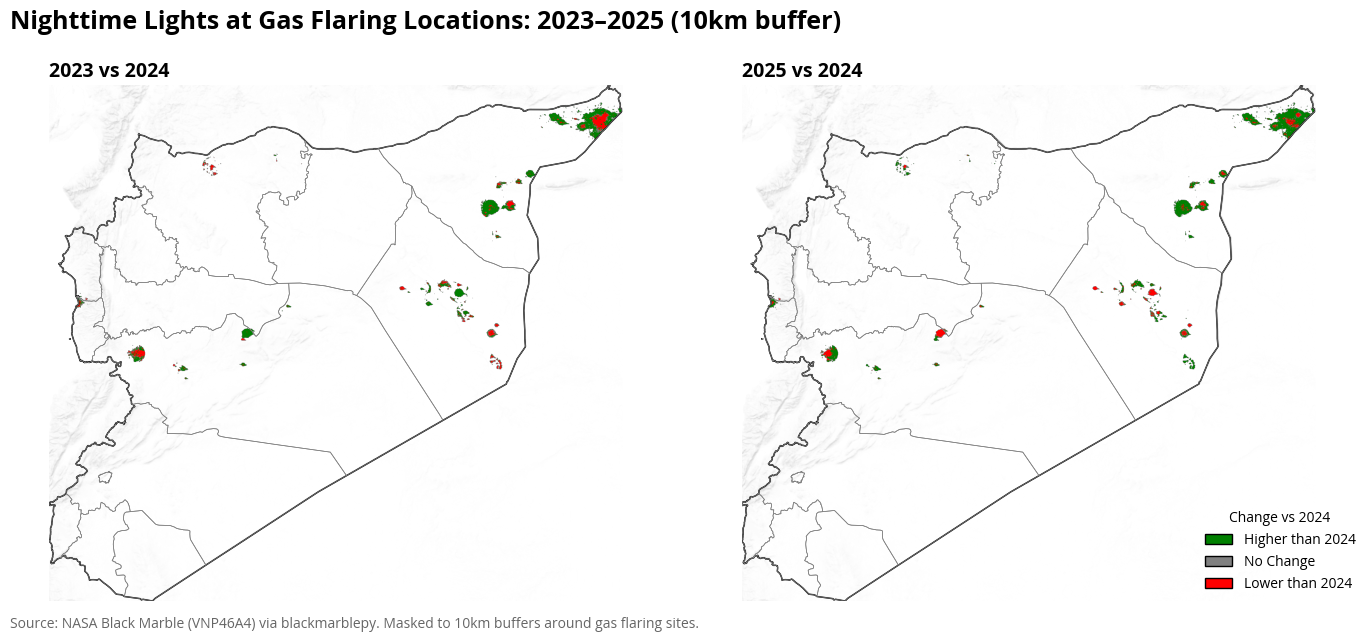

In [62]:
import os
import rasterio
import rasterio.mask
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
import pyreadr
import contextily as ctx
from dotenv import load_dotenv
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

load_dotenv()
MAPBOX_BASEMAP_URL = os.getenv('MAPBOX_BASEMAP_URL', '')
plt.rcParams['font.family'] = 'Open Sans'

# Load gas flaring locations and create 10km buffers (projected CRS for accuracy)
gas_flaring_rds = pyreadr.read_r('../../data/ntl/gas_flare_locations.Rds')
df_gas = next(iter(gas_flaring_rds.values()))
if 'geometry' in df_gas.columns:
    gas_flaring_gdf = gpd.GeoDataFrame(df_gas, geometry=gpd.GeoSeries.from_wkt(df_gas['geometry']), crs="EPSG:4326")
else:
    gas_flaring_gdf = gpd.GeoDataFrame(df_gas, geometry=gpd.points_from_xy(df_gas.longitude, df_gas.latitude), crs="EPSG:4326")

# Project to UTM zone 37N for accurate 10km buffer, then back to 4326
gas_flaring_proj = gas_flaring_gdf.to_crs(epsg=32637)
gas_flaring_proj['geometry_10km'] = gas_flaring_proj.geometry.buffer(10000)
buffers_4326 = gas_flaring_proj.set_geometry('geometry_10km').to_crs(epsg=4326)
shapes = [geom.__geo_interface__ for geom in buffers_4326.geometry]

raster_paths = {
    2023: DATA_DIR / 'ntl/raw/annual-raster_2023.tif',
    2024: DATA_DIR / 'ntl/raw/annual-raster_2024.tif',
    2025: DATA_DIR / 'ntl/raw/annual-raster_2025.tif',
}

# Load all masked arrays and get geographic extent from the raster
arrs = {}
raster_extent = None
for yr, path in raster_paths.items():
    with rasterio.open(path) as src:
        masked_arr, _ = rasterio.mask.mask(src, shapes, crop=False, filled=True, nodata=np.nan)
        arr = masked_arr[0].astype(float)
        arr[arr < 0.1] = np.nan
        arrs[yr] = arr
        if raster_extent is None:
            bounds = src.bounds
            raster_extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

# Build comparison arrays relative to 2024
ref = arrs[2024]
threshold = 0.05

def compare_to_ref(arr, ref, threshold=0.05):
    diff = arr - ref
    comp = np.zeros_like(diff)
    comp[diff > threshold] = 1
    comp[diff < -threshold] = -1
    comp[np.isnan(arr) | np.isnan(ref)] = np.nan
    return comp

arr_2023_comp = compare_to_ref(arrs[2023], ref, threshold)
arr_2025_comp = compare_to_ref(arrs[2025], ref, threshold)

cmap_compare = ListedColormap(['red', 'gray', 'green'])  # -1=lower, 0=no change, 1=higher

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

panels = [
    (arr_2023_comp, '2023 vs 2024'),
    (arr_2025_comp, '2025 vs 2024'),
]

for i, (arr, title) in enumerate(panels):
    masked = np.ma.masked_invalid(arr)
    axes[i].imshow(masked, cmap=cmap_compare, vmin=-1, vmax=1,
                   extent=raster_extent, origin='upper', aspect='auto', zorder=2)
    ctx.add_basemap(axes[i], crs='EPSG:4326', source=MAPBOX_BASEMAP_URL, alpha=0.3, zoom='auto', zorder=1)
    syria_adm0.plot(ax=axes[i], facecolor='none', edgecolor='black', linewidth=1, zorder=3)
    syria_adm1.boundary.plot(ax=axes[i], edgecolor='grey', linewidth=0.5, zorder=3)
    axes[i].set_title(title, fontsize=14, fontweight='bold', loc='left', fontfamily='Open Sans')
    axes[i].axis('off')

compare_legend = [
    Patch(facecolor='green', edgecolor='k', label='Higher than 2024'),
    Patch(facecolor='gray', edgecolor='k', label='No Change'),
    Patch(facecolor='red', edgecolor='k', label='Lower than 2024'),
]
fig.legend(handles=compare_legend, loc='lower right', ncol=1,
           bbox_to_anchor=(0.99, 0.02), frameon=False,
           title='Change vs 2024', prop={'family': 'Open Sans', 'size': 10})

fig.suptitle('Nighttime Lights at Gas Flaring Locations: 2023–2025 (10km buffer)',
             fontsize=18, fontweight='bold', fontfamily='Open Sans', x=0.02, ha='left', y=1.01)
fig.text(0.02, -0.02,
         'Source: NASA Black Marble (VNP46A4) via blackmarblepy. Masked to 10km buffers around gas flaring sites.',
         ha='left', fontsize=10, fontfamily='Open Sans', style='italic', color='#666666')
plt.tight_layout()
plt.show()


**Insights**
- In some areas there was a reduction in lights from gas flaring, but there was an increase in light from gas flaring in other in 2025 compared to 2024. 

### NTL Gas Flaring Location Change 2024 vs 2025

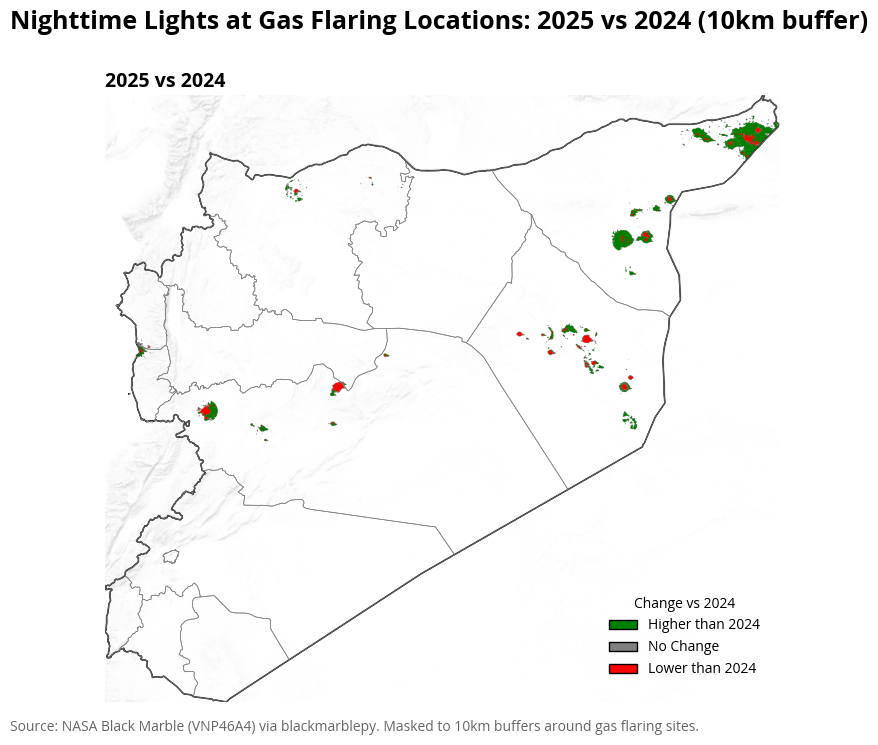

In [116]:

# 2025 vs 2024 only — gas flaring locations (annual product), self-contained

import os
import rasterio
import rasterio.mask
import numpy as np
import geopandas as gpd
import pyreadr
import contextily as ctx
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from dotenv import load_dotenv

load_dotenv()
MAPBOX_BASEMAP_URL = os.getenv('MAPBOX_BASEMAP_URL', '')
plt.rcParams['font.family'] = 'Open Sans'

syria_adm0 = gpd.read_file('../../data/boundaries/syr_admin0.shp')
syria_adm1 = gpd.read_file('../../data/boundaries/syr_admin1.shp')
syria_shapes = [geom.__geo_interface__ for geom in syria_adm0.geometry]

# Load gas flaring 10km buffer shapes
gas_flaring_rds = pyreadr.read_r('../../data/ntl/gas_flare_locations.Rds')
df_gas = next(iter(gas_flaring_rds.values()))
if 'geometry' in df_gas.columns:
    gas_flaring_gdf = gpd.GeoDataFrame(df_gas, geometry=gpd.GeoSeries.from_wkt(df_gas['geometry']), crs='EPSG:4326')
else:
    gas_flaring_gdf = gpd.GeoDataFrame(df_gas, geometry=gpd.points_from_xy(df_gas.longitude, df_gas.latitude), crs='EPSG:4326')
gas_flaring_proj = gas_flaring_gdf.to_crs(epsg=32637)
gas_flaring_proj['geometry_10km'] = gas_flaring_proj.geometry.buffer(10000)
buffers_4326 = gas_flaring_proj.set_geometry('geometry_10km').to_crs(epsg=4326)
gas_shapes = [geom.__geo_interface__ for geom in buffers_4326.geometry]

def load_masked_annual(path, clip_shapes):
    """Load annual raster masked to clip_shapes, return array + rasterio transform + bounds."""
    with rasterio.open(path) as src:
        masked_arr, transform = rasterio.mask.mask(src, clip_shapes, crop=False, filled=True, nodata=np.nan)
        arr = masked_arr[0].astype(float)
        nodata = src.nodata
        if nodata is not None:
            try:
                arr[arr == float(nodata)] = np.nan
            except Exception:
                pass
        arr[arr < 0.1] = np.nan
        bounds = src.bounds
    return arr, bounds

arr_2024, bounds_2024 = load_masked_annual(DATA_DIR / 'ntl/raw/annual-raster_2024.tif', gas_shapes)
arr_2025, bounds_2025 = load_masked_annual(DATA_DIR / 'ntl/raw/annual-raster_2025.tif', gas_shapes)

# Use Syria-clipped extent from adm0 bounds for the display window
syr_bounds = syria_adm0.total_bounds  # [minx, miny, maxx, maxy]
# Use raster extent for imshow placement (same bounds for both rasters)
extent = [bounds_2024.left, bounds_2024.right, bounds_2024.bottom, bounds_2024.top]

threshold = 0.05
diff = arr_2025 - arr_2024
comp = np.zeros_like(diff)
comp[diff > threshold]  =  1
comp[diff < -threshold] = -1
comp[np.isnan(arr_2024) | np.isnan(arr_2025)] = np.nan

cmap_compare = ListedColormap(['red', 'gray', 'green'])

fig, ax = plt.subplots(1, 1, figsize=(9, 7))

masked = np.ma.masked_invalid(comp)
ax.imshow(masked, cmap=cmap_compare, vmin=-1, vmax=1,
          extent=extent, origin='upper', aspect='auto', zorder=2)
ctx.add_basemap(ax, crs='EPSG:4326', source=MAPBOX_BASEMAP_URL, alpha=0.3, zoom='auto', zorder=1)
syria_adm0.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1, zorder=3)
syria_adm1.boundary.plot(ax=ax, edgecolor='grey', linewidth=0.5, zorder=3)

ax.set_xlim(syr_bounds[0], syr_bounds[2])
ax.set_ylim(syr_bounds[1], syr_bounds[3])
ax.set_title('2025 vs 2024', fontsize=14, fontweight='bold', loc='left', fontfamily='Open Sans')
ax.axis('off')

compare_legend = [
    Patch(facecolor='green', edgecolor='k', label='Higher than 2024'),
    Patch(facecolor='gray',  edgecolor='k', label='No Change'),
    Patch(facecolor='red',   edgecolor='k', label='Lower than 2024'),
]
ax.legend(handles=compare_legend, loc='lower right', ncol=1,
          bbox_to_anchor=(0.99, 0.02), frameon=False,
          title='Change vs 2024', prop={'family': 'Open Sans', 'size': 10})

fig.suptitle('Nighttime Lights at Gas Flaring Locations: 2025 vs 2024 (10km buffer)',
             fontsize=18, fontweight='bold', fontfamily='Open Sans', x=0.02, ha='left', y=1.01)
fig.text(0.02, -0.02,
         'Source: NASA Black Marble (VNP46A4) via blackmarblepy. Masked to 10km buffers around gas flaring sites.',
         ha='left', fontsize=10, fontfamily='Open Sans', style='italic', color='#666666')
plt.tight_layout()
plt.show()


### Trends in Annual Gas Flaring

In [132]:
import altair as alt

ntl_adm0_annual = pd.read_csv('../../data/ntl/aggregated/annual/ntl_syr_adm0_annual.csv')

chart = (
    alt.Chart(ntl_adm0_annual)
    .mark_bar()
    .encode(
        x=alt.X('date:O', axis=alt.Axis(title='Year', labelAngle=45)),
        y=alt.Y('ntl_gf_10km_sum:Q', axis=alt.Axis(title='NTL Sum (10km buffer)')),
        tooltip=['date:O', 'ntl_gf_10km_sum:Q'],
    )
    .properties(
        title=alt.TitleParams(
            text='Annual Nighttime Lights Sum at Gas Flaring Locations',
            anchor='start',
            subtitle='Source: NASA Black Marble (VNP46A4) via blackmarblepy. Aggregated within 10km buffers around gas flaring sites.',
            subtitleColor='#666666',
        ),
        width=500,
        height=300,
    )
)

chart


alt.Chart(...)

At a national level the total sum of lights around gas flaring locations remains very similar in 2025 to 2024. 

In [137]:
import altair as alt

ntl_adm1_annual = pd.read_csv('../../data/ntl/aggregated/annual/ntl_syr_adm1_annual.csv')

# Keep only communes that have ntl_gf_10km_sum > 0 in at least one year
communes_with_flaring = (
    ntl_adm1_annual[ntl_adm1_annual['ntl_gf_10km_sum'] > 0]['NAME_EN'].unique()
)
df_filtered = ntl_adm1_annual[ntl_adm1_annual['NAME_EN'].isin(communes_with_flaring)]

chart = (
    alt.Chart(df_filtered)
    .mark_bar()
    .encode(
        x=alt.X('date:T', axis=alt.Axis(title='', labelAngle=45, format='%Y-%m')),
        y=alt.Y('ntl_gf_10km_sum:Q', axis=alt.Axis(title=None)),
        tooltip=['NAME_EN:N', 'date:T', 'ntl_gf_10km_sum:Q'],
    )
    .properties(width=110, height=120)
    .facet(
        facet=alt.Facet('NAME_EN:N', title=None),
        columns=4,
        title=alt.TitleParams(
            text='Annual NTL Sum at Gas Flaring Locations by Governorate',
            anchor='start',
            subtitle='Source: NASA Black Marble (VNP46A4). Governorates with ntl_gf_10km_sum > 0 in at least one year.',
            subtitleColor='#666666',
        ),
    )
    .resolve_scale(y='independent')
)

chart


alt.FacetChart(...)

At a regional level, the lights increased in Al-Hasakeh and Aleppo but reduced in Homs, Der-ez-Zor. 

In [109]:
import os
import rasterio
import rasterio.enums
import rasterio.transform
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from pathlib import Path

load_dotenv()

# --- Canonical reference grid from first VNP46A3 monthly file ---
_ref_file = DATA_DIR / 'ntl/raw/VNP46A3_NearNadir_Composite_Snow_Free_qflag_t2023_09.tif'
with rasterio.open(_ref_file) as _src:
    REF_HEIGHT = _src.height
    REF_WIDTH = _src.width
    REF_TRANSFORM = _src.transform
    REF_CRS = _src.crs
    _b = _src.bounds
    RASTER_EXTENT = [_b.left, _b.right, _b.bottom, _b.top]

print(f"Reference grid: {REF_HEIGHT} x {REF_WIDTH}, CRS: {REF_CRS}")

def average_monthly_rasters(date_range, data_dir, ref_height, ref_width):
    """Load VNP46A3 monthly TIFs and compute pixel-wise mean, resampling to canonical grid."""
    arrays = []
    for dt in date_range:
        fname = data_dir / f'ntl/raw/VNP46A3_NearNadir_Composite_Snow_Free_qflag_t{dt.strftime("%Y_%m")}.tif'
        if not fname.exists():
            print(f"  Missing: {fname.name}, skipping")
            continue
        with rasterio.open(fname) as src:
            band = src.read(
                1,
                out_shape=(ref_height, ref_width),
                resampling=rasterio.enums.Resampling.bilinear,
                masked=True
            )
            arr = band.filled(np.nan).astype(float)
            nodata = src.nodata
            if nodata is not None and not np.isnan(float(nodata)):
                arr[arr == nodata] = np.nan
            arr[arr < 0.1] = np.nan  # mask low/no-light pixels
            arrays.append(arr)
    if not arrays:
        print("  No files loaded!")
        return None
    mean_arr = np.nanmean(np.stack(arrays, axis=0), axis=0)
    valid_px = np.sum(~np.isnan(mean_arr))
    print(f"  Averaged {len(arrays)} rasters — {valid_px:,} valid pixels in result")
    return mean_arr

def save_average_raster(arr, out_path, transform, crs):
    """Save a 2D float array as a single-band GeoTIFF."""
    with rasterio.open(
        out_path, 'w',
        driver='GTiff',
        height=arr.shape[0],
        width=arr.shape[1],
        count=1,
        dtype='float32',
        crs=crs,
        transform=transform,
        nodata=np.nan
    ) as dst:
        dst.write(arr.astype('float32'), 1)
    print(f"  Saved: {out_path}")

# Exclude June (6), July (7), August (8) — summer months with lower NTL reliability
SUMMER_MONTHS = {6, 7, 8}

period1_dates = [d for d in pd.date_range('2023-09-01', '2024-11-01', freq='MS')
                 if d.month not in SUMMER_MONTHS]
period2_dates = [d for d in pd.date_range('2025-01-01', '2026-01-01', freq='MS')
                 if d.month not in SUMMER_MONTHS]

print(f"Period 1 months ({len(period1_dates)}): {[d.strftime('%Y-%m') for d in period1_dates]}")
print(f"Period 2 months ({len(period2_dates)}): {[d.strftime('%Y-%m') for d in period2_dates]}")

avg1_path = DATA_DIR / 'ntl/raw/avg_monthly_pre_regime_change.tif'
avg2_path = DATA_DIR / 'ntl/raw/avg_monthly_post_regime_change.tif'

print("\nComputing Period 1 average (Sep 2023 – Nov 2024, excl. Jun–Aug)...")
avg1 = average_monthly_rasters(period1_dates, DATA_DIR, REF_HEIGHT, REF_WIDTH)
save_average_raster(avg1, avg1_path, REF_TRANSFORM, REF_CRS)

print("Computing Period 2 average (Jan 2025 – Jan 2026, excl. Jun–Aug)...")
avg2 = average_monthly_rasters(period2_dates, DATA_DIR, REF_HEIGHT, REF_WIDTH)
save_average_raster(avg2, avg2_path, REF_TRANSFORM, REF_CRS)

print("Done.")


Reference grid: 1201 x 1625, CRS: EPSG:4326
Period 1 months (12): ['2023-09', '2023-10', '2023-11', '2023-12', '2024-01', '2024-02', '2024-03', '2024-04', '2024-05', '2024-09', '2024-10', '2024-11']
Period 2 months (10): ['2025-01', '2025-02', '2025-03', '2025-04', '2025-05', '2025-09', '2025-10', '2025-11', '2025-12', '2026-01']

Computing Period 1 average (Sep 2023 – Nov 2024, excl. Jun–Aug)...
  Averaged 12 rasters — 685,333 valid pixels in result
  Saved: ../../data/ntl/raw/avg_monthly_pre_regime_change.tif
Computing Period 2 average (Jan 2025 – Jan 2026, excl. Jun–Aug)...
  Averaged 10 rasters — 751,425 valid pixels in result
  Saved: ../../data/ntl/raw/avg_monthly_post_regime_change.tif
Done.


/var/folders/gs/_227cnyd0pq1fr817_0jbcyw0000gp/T/ipykernel_30979/2218501229.py:48: RuntimeWarning: Mean of empty slice
  mean_arr = np.nanmean(np.stack(arrays, axis=0), axis=0)


## Aggregated Monthly Change in Nightlights

To compare nighttime light levels before and after the regime change, monthly rasters from the NASA Black Marble VNP46A3 product were averaged into two periods:

- **Pre-regime change**: September 2023 – November 2024
- **Post-regime change**: January 2025 – January 2026

June, July, and August were excluded from both periods. Summer months tend to have lower NTL data quality in this region due to reduced contrast between ambient light and sky brightness, leading to noisier readings that could obscure real changes in economic activity.

Pixels with NTL values below 0.1 are also masked out, as these are indistinguishable from background noise.


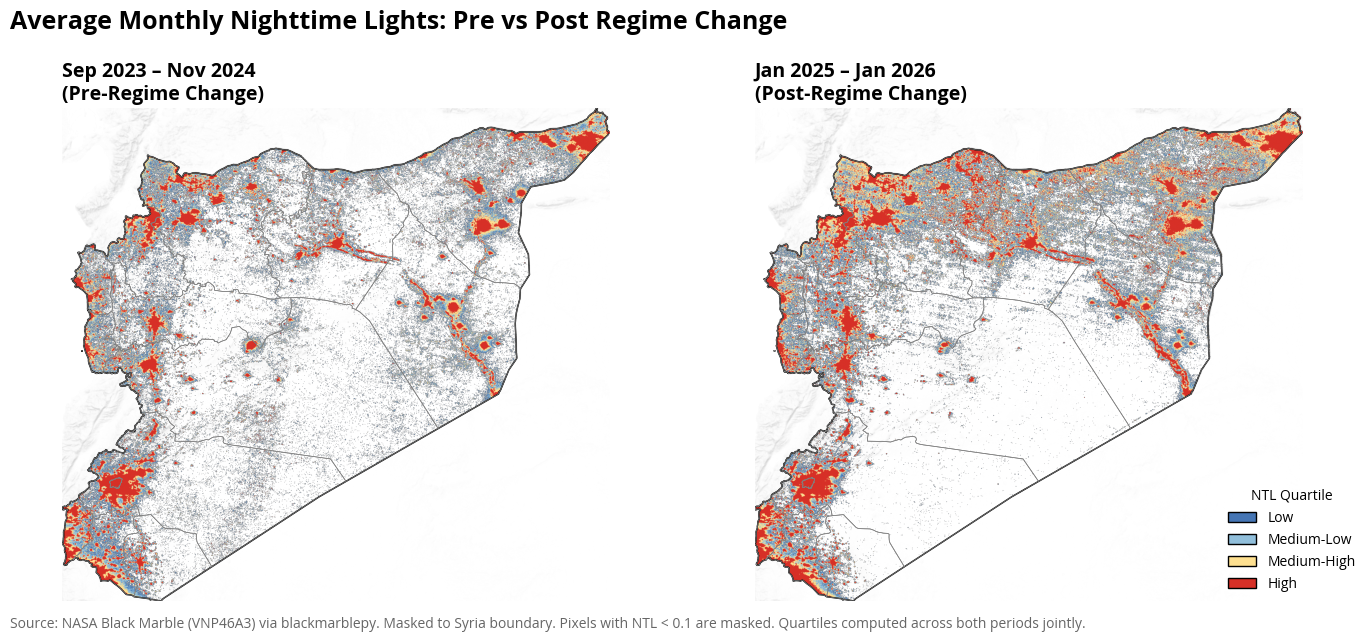

In [ ]:
import rasterio
import rasterio.mask
import numpy as np
import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

plt.rcParams['font.family'] = 'Open Sans'

syria_adm0 = gpd.read_file('../../data/boundaries/syr_admin0.shp')
syria_adm1 = gpd.read_file('../../data/boundaries/syr_admin1.shp')

# Get Syria boundary shapes for masking
syria_shapes = [geom.__geo_interface__ for geom in syria_adm0.geometry]

avg1_path = DATA_DIR / 'ntl/raw/avg_monthly_pre_regime_change.tif'
avg2_path = DATA_DIR / 'ntl/raw/avg_monthly_post_regime_change.tif'

def load_avg_raster(path, clip_shapes):
    with rasterio.open(path) as src:
        masked_band, _ = rasterio.mask.mask(src, clip_shapes, crop=False, filled=True, nodata=np.nan)
        arr = masked_band[0].astype(float)
        nodata = src.nodata
        if nodata is not None and not np.isnan(float(nodata)):
            arr[arr == nodata] = np.nan
        arr[arr < 0.1] = np.nan  # mask low/no-light pixels
        b = src.bounds
        extent = [b.left, b.right, b.bottom, b.top]
    return arr, extent

avg1, extent = load_avg_raster(avg1_path, syria_shapes)
avg2, _     = load_avg_raster(avg2_path, syria_shapes)

# Quartile breakpoints computed jointly across both periods
all_vals = np.concatenate([avg1[~np.isnan(avg1)], avg2[~np.isnan(avg2)]])
q = np.nanquantile(all_vals, [0.25, 0.5, 0.75])

quartile_labels = ['Low', 'Medium-Low', 'Medium-High', 'High']
quartile_colors = ['#4575b4', '#91bfdb', '#fee090', '#d73027']
cmap = ListedColormap(quartile_colors)

def to_quartile(arr, q):
    qmap = np.digitize(arr, q, right=True).astype(float)
    qmap[np.isnan(arr)] = np.nan
    return np.ma.masked_invalid(qmap)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

panels = [
    (avg1, 'Sep 2023 – Nov 2024\n(Pre-Regime Change)'),
    (avg2, 'Jan 2025 – Jan 2026\n(Post-Regime Change)'),
]

for i, (arr, title) in enumerate(panels):
    qmap = to_quartile(arr, q)
    axes[i].imshow(qmap, cmap=cmap, vmin=0, vmax=3,
                   extent=extent, origin='upper', aspect='auto', zorder=2)
    ctx.add_basemap(axes[i], crs='EPSG:4326', source=MAPBOX_BASEMAP_URL,
                    alpha=0.3, zoom='auto', zorder=1)
    syria_adm0.plot(ax=axes[i], facecolor='none', edgecolor='black', linewidth=1, zorder=3)
    syria_adm1.boundary.plot(ax=axes[i], edgecolor='grey', linewidth=0.5, zorder=3)
    axes[i].set_title(title, fontsize=14, fontweight='bold', loc='left', fontfamily='Open Sans')
    axes[i].axis('off')

legend_elements = [
    Patch(facecolor=quartile_colors[j], edgecolor='k', label=quartile_labels[j])
    for j in range(4)
]
fig.legend(handles=legend_elements, loc='lower right', ncol=1,
           bbox_to_anchor=(0.99, 0.02), frameon=False,
           title='NTL Quartile', prop={'family': 'Open Sans', 'size': 10})

fig.suptitle('Average Monthly Nighttime Lights: Pre vs Post Regime Change',
             fontsize=18, fontweight='bold', fontfamily='Open Sans', x=0.02, ha='left', y=1.01)
fig.text(0.02, -0.02,
         'Source: NASA Black Marble (VNP46A3) via blackmarblepy. Masked to Syria boundary. Pixels with NTL < 0.1 are masked. Quartiles computed across both periods jointly.',
         ha='left', fontsize=10, fontfamily='Open Sans', style='italic', color='#666666')
plt.tight_layout()

plt.show()


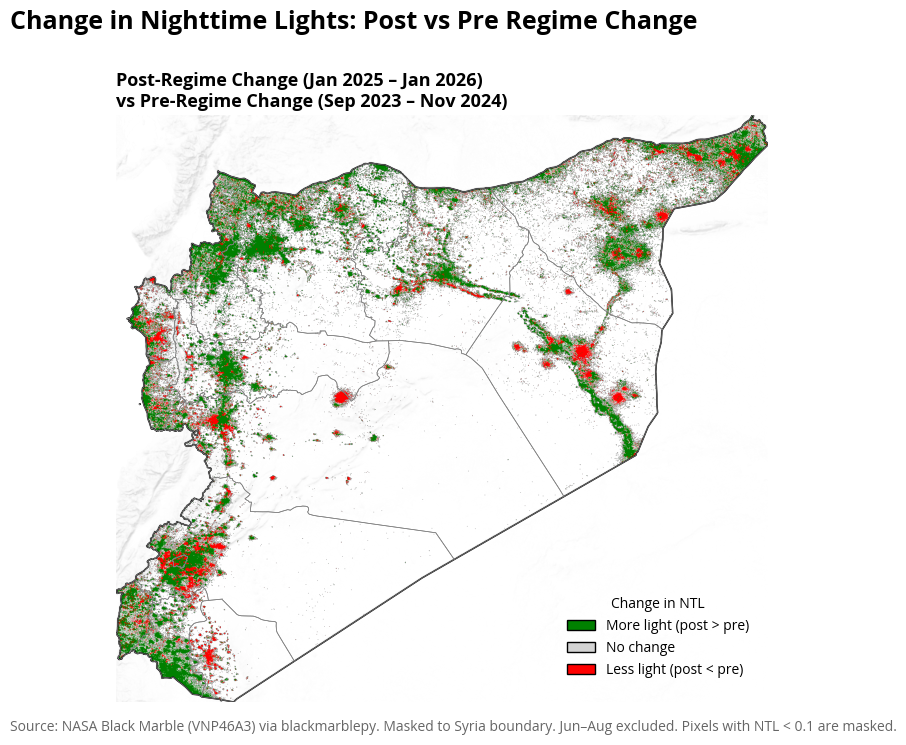

In [111]:
import numpy as np
import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

plt.rcParams['font.family'] = 'Open Sans'

# avg1, avg2, extent, syria_shapes already loaded from previous cell
# Compute change: post minus pre
diff = avg2 - avg1

threshold = 0.05
change = np.zeros_like(diff)
change[diff > threshold]  =  1   # more light
change[diff < -threshold] = -1   # less light
change[np.isnan(avg1) | np.isnan(avg2)] = np.nan

cmap_compare = ListedColormap(['red', 'lightgrey', 'green'])  # -1, 0, 1

fig, ax = plt.subplots(1, 1, figsize=(9, 7))

masked_change = np.ma.masked_invalid(change)
ax.imshow(masked_change, cmap=cmap_compare, vmin=-1, vmax=1,
          extent=extent, origin='upper', aspect='auto', zorder=2)
ctx.add_basemap(ax, crs='EPSG:4326', source=MAPBOX_BASEMAP_URL,
                alpha=0.3, zoom='auto', zorder=1)

syria_adm0 = gpd.read_file('../../data/boundaries/syr_admin0.shp')
syria_adm1 = gpd.read_file('../../data/boundaries/syr_admin1.shp')
syria_adm0.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1, zorder=3)
syria_adm1.boundary.plot(ax=ax, edgecolor='grey', linewidth=0.5, zorder=3)
ax.set_title('Post-Regime Change (Jan 2025 – Jan 2026)\nvs Pre-Regime Change (Sep 2023 – Nov 2024)',
             fontsize=13, fontweight='bold', loc='left', fontfamily='Open Sans')
ax.axis('off')

legend_elements = [
    Patch(facecolor='green',     edgecolor='k', label='More light (post > pre)'),
    Patch(facecolor='lightgrey', edgecolor='k', label='No change'),
    Patch(facecolor='red',       edgecolor='k', label='Less light (post < pre)'),
]
ax.legend(handles=legend_elements, loc='lower right',
          bbox_to_anchor=(0.99, 0.02), frameon=False,
          title='Change in NTL', prop={'family': 'Open Sans', 'size': 10})

fig.suptitle('Change in Nighttime Lights: Post vs Pre Regime Change',
             fontsize=18, fontweight='bold', fontfamily='Open Sans', x=0.02, ha='left', y=1.01)
fig.text(0.02, -0.02,
         'Source: NASA Black Marble (VNP46A3) via blackmarblepy. Masked to Syria boundary. Jun–Aug excluded. Pixels with NTL < 0.1 are masked.',
         ha='left', fontsize=10, fontfamily='Open Sans', style='italic', color='#666666')
plt.tight_layout()
plt.show()


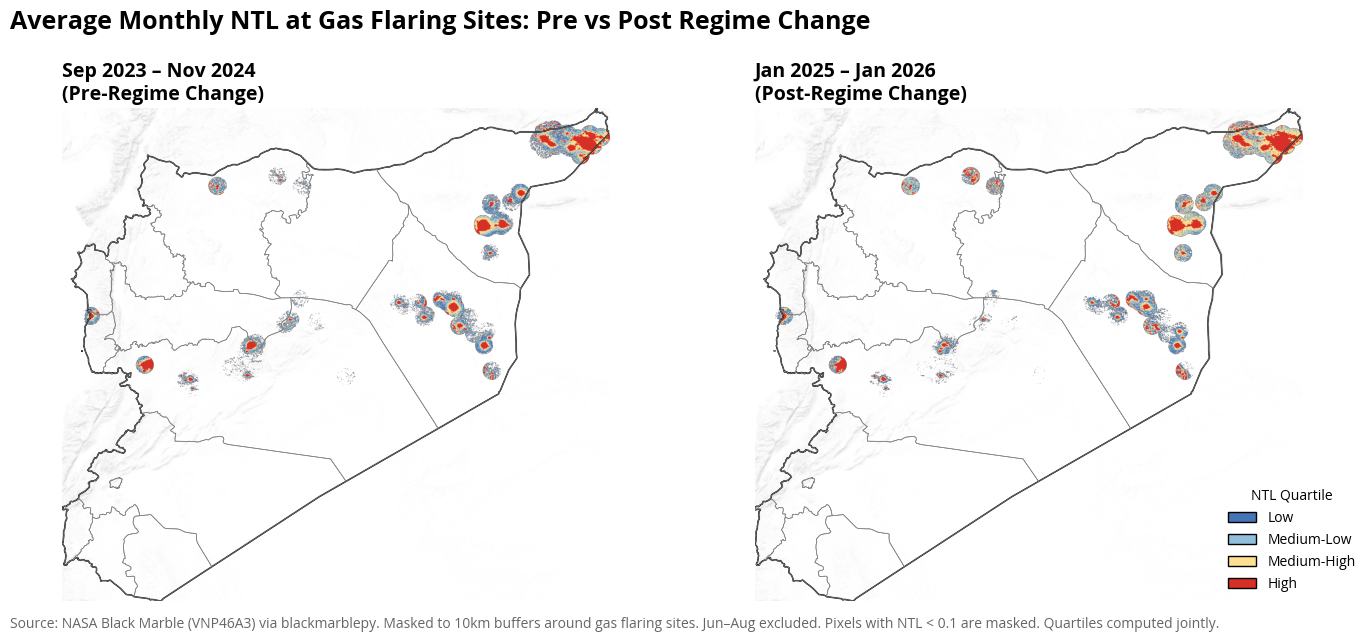

In [112]:
import rasterio
import rasterio.mask
import numpy as np
import geopandas as gpd
import pyreadr
import contextily as ctx
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

plt.rcParams['font.family'] = 'Open Sans'

syria_adm0 = gpd.read_file('../../data/boundaries/syr_admin0.shp')
syria_adm1 = gpd.read_file('../../data/boundaries/syr_admin1.shp')

# Build 10km buffer shapes around gas flaring locations
gas_flaring_rds = pyreadr.read_r('../../data/ntl/gas_flare_locations.Rds')
df_gas = next(iter(gas_flaring_rds.values()))
if 'geometry' in df_gas.columns:
    gas_flaring_gdf = gpd.GeoDataFrame(df_gas, geometry=gpd.GeoSeries.from_wkt(df_gas['geometry']), crs='EPSG:4326')
else:
    gas_flaring_gdf = gpd.GeoDataFrame(df_gas, geometry=gpd.points_from_xy(df_gas.longitude, df_gas.latitude), crs='EPSG:4326')

gas_flaring_proj = gas_flaring_gdf.to_crs(epsg=32637)
gas_flaring_proj['geometry_10km'] = gas_flaring_proj.geometry.buffer(10000)
buffers_4326 = gas_flaring_proj.set_geometry('geometry_10km').to_crs(epsg=4326)
gas_shapes = [geom.__geo_interface__ for geom in buffers_4326.geometry]

avg1_path = DATA_DIR / 'ntl/raw/avg_monthly_pre_regime_change.tif'
avg2_path = DATA_DIR / 'ntl/raw/avg_monthly_post_regime_change.tif'

def load_avg_raster_gas(path, clip_shapes):
    with rasterio.open(path) as src:
        masked_band, _ = rasterio.mask.mask(src, clip_shapes, crop=False, filled=True, nodata=np.nan)
        arr = masked_band[0].astype(float)
        nodata = src.nodata
        if nodata is not None and not np.isnan(float(nodata)):
            arr[arr == nodata] = np.nan
        arr[arr < 0.1] = np.nan
        b = src.bounds
        extent = [b.left, b.right, b.bottom, b.top]
    return arr, extent

avg1_gas, extent_gas = load_avg_raster_gas(avg1_path, gas_shapes)
avg2_gas, _          = load_avg_raster_gas(avg2_path, gas_shapes)

# Quartile breakpoints computed jointly across both periods
all_vals_gas = np.concatenate([avg1_gas[~np.isnan(avg1_gas)], avg2_gas[~np.isnan(avg2_gas)]])
q_gas = np.nanquantile(all_vals_gas, [0.25, 0.5, 0.75])

quartile_labels = ['Low', 'Medium-Low', 'Medium-High', 'High']
quartile_colors = ['#4575b4', '#91bfdb', '#fee090', '#d73027']
cmap_q = ListedColormap(quartile_colors)

def to_quartile(arr, q):
    qmap = np.digitize(arr, q, right=True).astype(float)
    qmap[np.isnan(arr)] = np.nan
    return np.ma.masked_invalid(qmap)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

panels = [
    (avg1_gas, 'Sep 2023 – Nov 2024\n(Pre-Regime Change)'),
    (avg2_gas, 'Jan 2025 – Jan 2026\n(Post-Regime Change)'),
]

for i, (arr, title) in enumerate(panels):
    qmap = to_quartile(arr, q_gas)
    axes[i].imshow(qmap, cmap=cmap_q, vmin=0, vmax=3,
                   extent=extent_gas, origin='upper', aspect='auto', zorder=2)
    ctx.add_basemap(axes[i], crs='EPSG:4326', source=MAPBOX_BASEMAP_URL,
                    alpha=0.3, zoom='auto', zorder=1)
    syria_adm0.plot(ax=axes[i], facecolor='none', edgecolor='black', linewidth=1, zorder=3)
    syria_adm1.boundary.plot(ax=axes[i], edgecolor='grey', linewidth=0.5, zorder=3)
    axes[i].set_title(title, fontsize=14, fontweight='bold', loc='left', fontfamily='Open Sans')
    axes[i].axis('off')

legend_elements = [
    Patch(facecolor=quartile_colors[j], edgecolor='k', label=quartile_labels[j])
    for j in range(4)
]
fig.legend(handles=legend_elements, loc='lower right', ncol=1,
           bbox_to_anchor=(0.99, 0.02), frameon=False,
           title='NTL Quartile', prop={'family': 'Open Sans', 'size': 10})

fig.suptitle('Average Monthly NTL at Gas Flaring Sites: Pre vs Post Regime Change',
             fontsize=18, fontweight='bold', fontfamily='Open Sans', x=0.02, ha='left', y=1.01)
fig.text(0.02, -0.02,
         'Source: NASA Black Marble (VNP46A3) via blackmarblepy. Masked to 10km buffers around gas flaring sites. Jun–Aug excluded. Pixels with NTL < 0.1 are masked. Quartiles computed jointly.',
         ha='left', fontsize=10, fontfamily='Open Sans', style='italic', color='#666666')
plt.tight_layout()
plt.show()


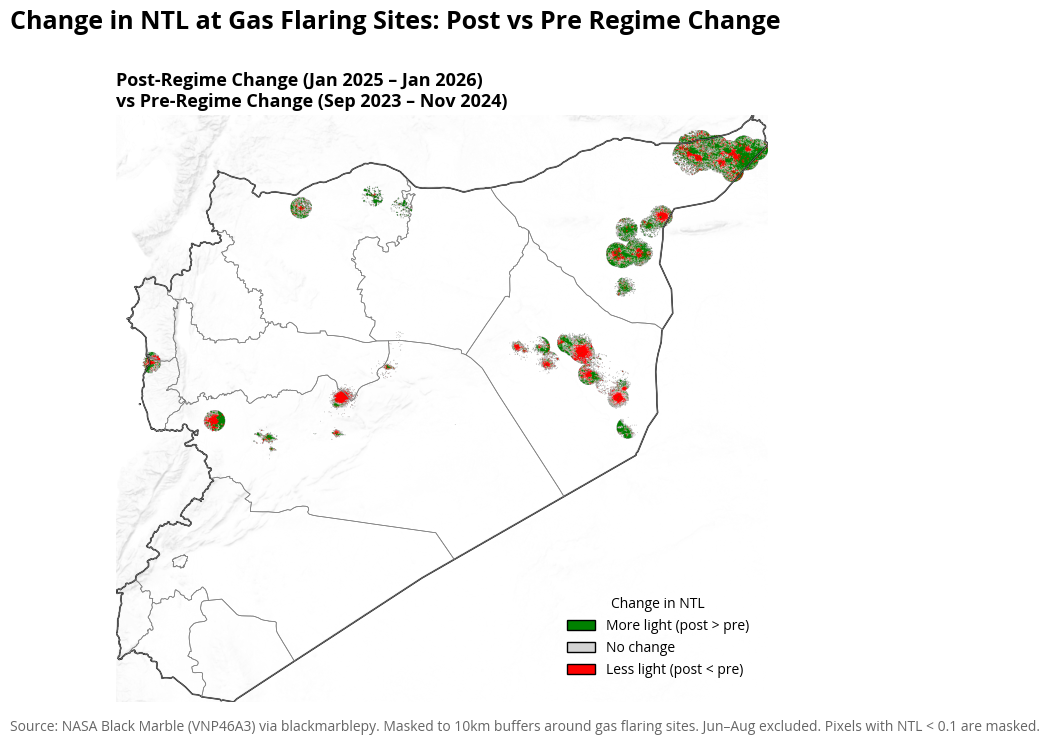

In [113]:
import numpy as np
import contextily as ctx
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

plt.rcParams['font.family'] = 'Open Sans'

# avg1_gas, avg2_gas, extent_gas, gas_shapes loaded from previous cell
diff_gas = avg2_gas - avg1_gas

threshold = 0.05
change_gas = np.zeros_like(diff_gas)
change_gas[diff_gas > threshold]  =  1
change_gas[diff_gas < -threshold] = -1
change_gas[np.isnan(avg1_gas) | np.isnan(avg2_gas)] = np.nan

cmap_compare = ListedColormap(['red', 'lightgrey', 'green'])

fig, ax = plt.subplots(1, 1, figsize=(9, 7))

masked_change = np.ma.masked_invalid(change_gas)
ax.imshow(masked_change, cmap=cmap_compare, vmin=-1, vmax=1,
          extent=extent_gas, origin='upper', aspect='auto', zorder=2)
ctx.add_basemap(ax, crs='EPSG:4326', source=MAPBOX_BASEMAP_URL,
                alpha=0.3, zoom='auto', zorder=1)
syria_adm0.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1, zorder=3)
syria_adm1.boundary.plot(ax=ax, edgecolor='grey', linewidth=0.5, zorder=3)
ax.set_title('Post-Regime Change (Jan 2025 – Jan 2026)\nvs Pre-Regime Change (Sep 2023 – Nov 2024)',
             fontsize=13, fontweight='bold', loc='left', fontfamily='Open Sans')
ax.axis('off')

legend_elements = [
    Patch(facecolor='green',     edgecolor='k', label='More light (post > pre)'),
    Patch(facecolor='lightgrey', edgecolor='k', label='No change'),
    Patch(facecolor='red',       edgecolor='k', label='Less light (post < pre)'),
]
ax.legend(handles=legend_elements, loc='lower right',
          bbox_to_anchor=(0.99, 0.02), frameon=False,
          title='Change in NTL', prop={'family': 'Open Sans', 'size': 10})

fig.suptitle('Change in NTL at Gas Flaring Sites: Post vs Pre Regime Change',
             fontsize=18, fontweight='bold', fontfamily='Open Sans', x=0.02, ha='left', y=1.01)
fig.text(0.02, -0.02,
         'Source: NASA Black Marble (VNP46A3) via blackmarblepy. Masked to 10km buffers around gas flaring sites. Jun–Aug excluded. Pixels with NTL < 0.1 are masked.',
         ha='left', fontsize=10, fontfamily='Open Sans', style='italic', color='#666666')
plt.tight_layout()
plt.show()
